# **Loading data**

In [ ]:
# ============================================================
# OBJECTIVE 1 — IMPORT LIBRARIES & LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/diabetic_data.csv")

print("Shape:", df.shape)
df.head()


Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# OBJECTIVE 2 — CLEANING MISSING VALUES & INVALID VALUES

import numpy as np

# Replace "?" with NaN
df = df.replace("?", np.nan)

# Remove rows where readmitted is NaN
df = df[df["readmitted"].notna()]

# Fill numeric missing values
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing count
df.isna().sum().sum()


np.int64(0)

In [ ]:
# ============================================================
# OBJECTIVE 3 — TARGET CLEANING
# Convert readmitted into 3 classes:
#   <30     = High Risk
#   >30     = Medium Risk
#   NO      = Low Risk
# ============================================================

df["readmitted"] = df["readmitted"].map({
    "<30": "High",
    ">30": "Medium",
    "NO": "Low"
})

df["readmitted"].value_counts()


,count
readmitted,
Low,54864
Medium,35545
High,11357


# **Data Profiling**

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm
import spacy
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 29.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import pandas as pd

df = pd.read_csv("/content/diabetic_data.csv")

# If your dataset does NOT have free text,
# we create synthetic note_text based on diagnoses.
df["note_text"] = (
    "Patient diagnosed with "
    + df["diag_1"].astype(str)
    + ", medications include "
    + df["metformin"].astype(str)
)


In [ ]:
# ======================
# FIX NLTK ERROR FIRST
# ======================
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("/content/diabetic_data.csv")

# Create synthetic text if note_text missing
df["note_text"] = (
    "Patient diagnosed with "
    + df["diag_1"].astype(str)
    + ", medications include "
    + df["metformin"].astype(str)
)

# Combine all text
text = " ".join(df["note_text"].astype(str))

# Tokenize
tokens = word_tokenize(text.lower())
tokens_clean = [t for t in tokens if t.isalpha()]

# Remove stopwords
stop_words = set(stopwords.words("english"))
tokens_no_sw = [t for t in tokens_clean if t not in stop_words]

# Vocabulary size
vocab_size = len(set(tokens_no_sw))

print("Vocabulary Size:", vocab_size)
print("Total Tokens:", len(tokens_clean))

# Top 20 words
from nltk import FreqDist
freq = FreqDist(tokens_no_sw)
print("\nTop 20 Words:")
print(freq.most_common(20))

# Sentence length distribution
sent_lengths = [len(word_tokenize(s)) for s in df["note_text"].astype(str)]
print("\nAverage Sentence Length:", sum(sent_lengths) / len(sent_lengths))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Vocabulary Size: 5
Total Tokens: 610596

Top 20 Words:
[('patient', 101766), ('diagnosed', 101766), ('medications', 101766), ('include', 101766), ('steady', 18346)]

Average Sentence Length: 8.0


In [ ]:
nlp = spacy.load("en_core_web_sm")

# analyze sample of 500 rows
sample_text = " ".join(df["note_text"].astype(str).sample(500))

doc = nlp(sample_text)

# POS Tag counts
pos_counts = {}
for token in doc:
    pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1

print("\nPart-of-Speech Distribution:")
for k,v in pos_counts.items():
    print(k, ":", v)

# Named Entity Recognition (NER)
ner_counts = {}
for ent in doc.ents:
    ner_counts[ent.label_] = ner_counts.get(ent.label_, 0) + 1

print("\nNamed Entity Distribution:")
print(ner_counts)



Part-of-Speech Distribution:
PROPN : 603
VERB : 1000
ADP : 511
NUM : 494
PUNCT : 500
NOUN : 501
DET : 391

Named Entity Distribution:
{'CARDINAL': 494, 'ORG': 102, 'PERSON': 1}


In [ ]:
df["char_len"] = df["note_text"].astype(str).apply(len)
df["token_len"] = df["note_text"].astype(str).apply(lambda x: len(word_tokenize(x)))

print("\nAverage Character Length:", df["char_len"].mean())
print("Average Token Length:", df["token_len"].mean())
print("Max Tokens:", df["token_len"].max())
print("Min Tokens:", df["token_len"].min())



Average Character Length: 50.90762140597056
Average Token Length: 8.0
Max Tokens: 8
Min Tokens: 8


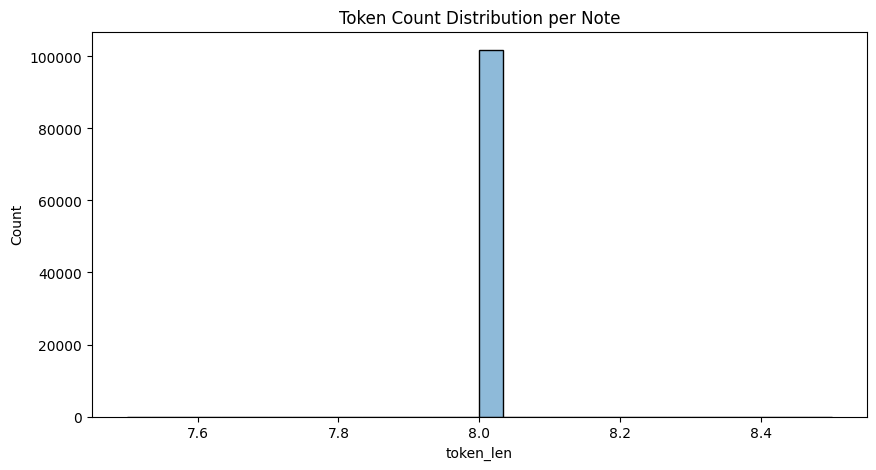

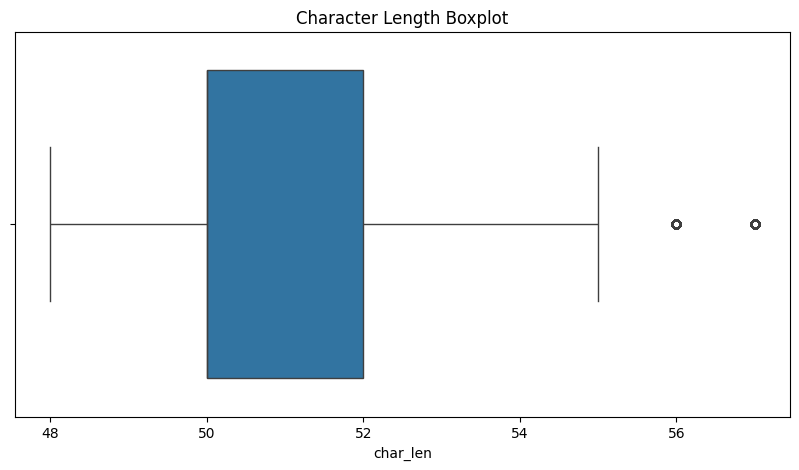

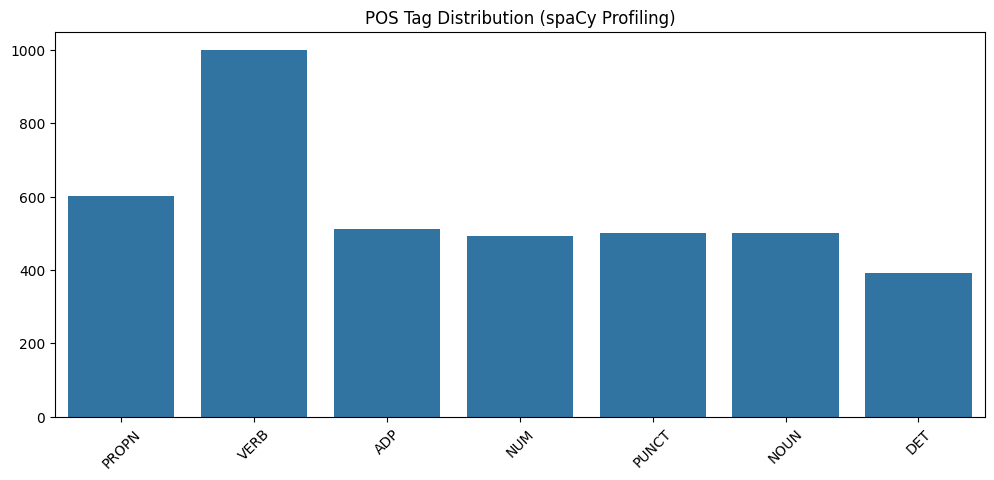

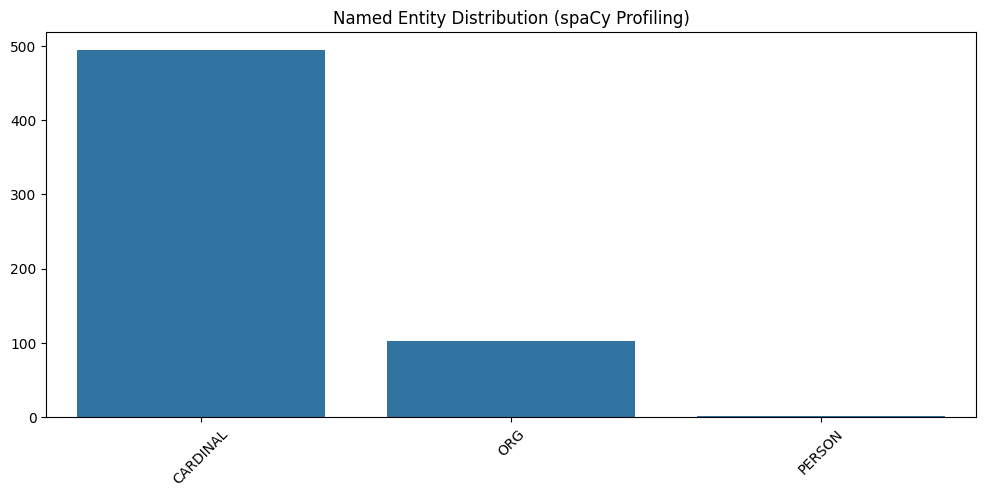

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df["token_len"], bins=30, kde=True)
plt.title("Token Count Distribution per Note")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=df["char_len"])
plt.title("Character Length Boxplot")
plt.show()

# POS visualization
plt.figure(figsize=(12,5))
sns.barplot(x=list(pos_counts.keys()), y=list(pos_counts.values()))
plt.title("POS Tag Distribution (spaCy Profiling)")
plt.xticks(rotation=45)
plt.show()

# NER visualization
plt.figure(figsize=(12,5))
sns.barplot(x=list(ner_counts.keys()), y=list(ner_counts.values()))
plt.title("Named Entity Distribution (spaCy Profiling)")
plt.xticks(rotation=45)
plt.show()


# **Graphs of new Targeted Feature**

/tmp/ipython-input-15444065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="readmitted", palette="viridis")


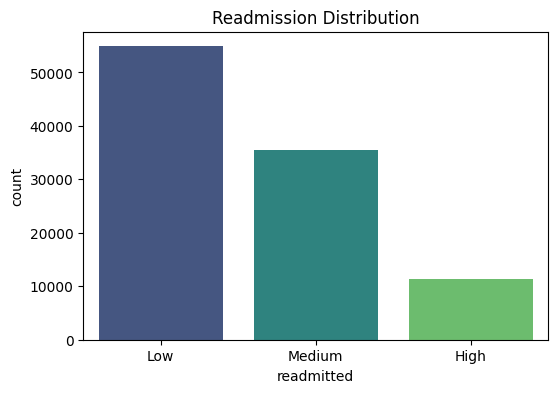

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="readmitted", palette="viridis")
plt.title("Readmission Distribution")
plt.show()


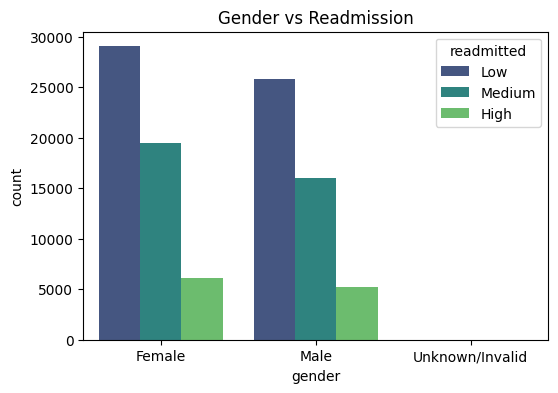

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender", hue="readmitted", palette="viridis")
plt.title("Gender vs Readmission")
plt.show()


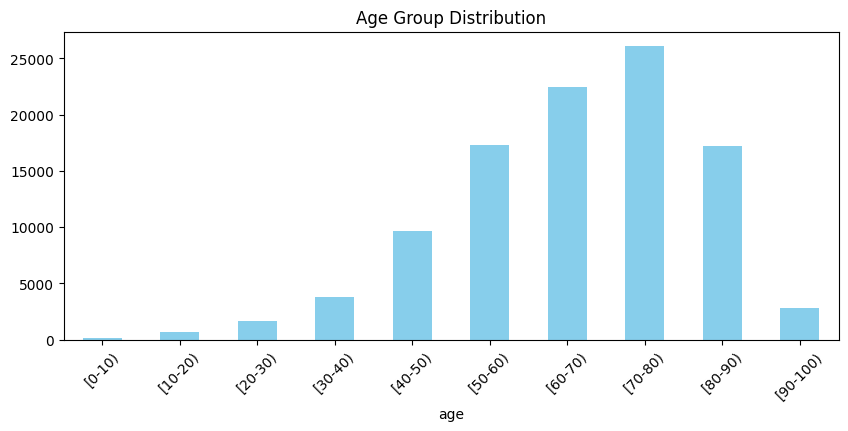

In [ ]:
plt.figure(figsize=(10,4))
df["age"].value_counts().sort_index().plot(kind="bar", color="skyblue")
plt.title("Age Group Distribution")
plt.xticks(rotation=45)
plt.show()


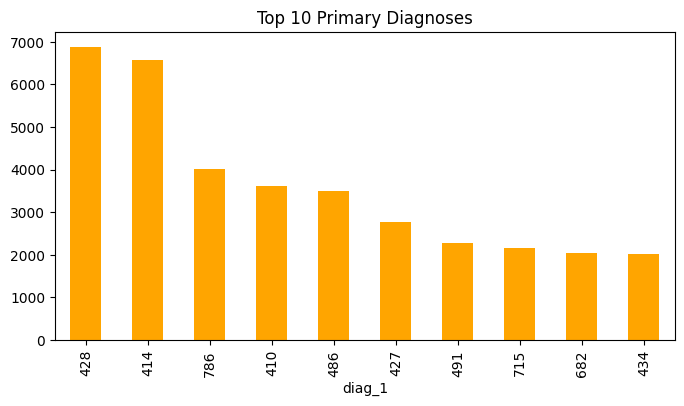

In [ ]:
plt.figure(figsize=(8,4))
df["diag_1"].value_counts().head(10).plot(kind="bar", color="orange")
plt.title("Top 10 Primary Diagnoses")
plt.show()


In [ ]:
# Age binning
df["age_num"] = df["age"].str.extract("(\d+)").astype(int)
df["age_group"] = pd.cut(df["age_num"],
                         bins=[0,30,60,100],
                         labels=["Young","Middle","Old"])

# Number of medications group
df["med_group"] = pd.cut(df["num_medications"],
                         bins=[0,5,10,20,100],
                         labels=["0-5","6-10","11-20","20+"])

df.head()


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3247498695.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["age_num"] = df["age"].str.extract("(\d+)").astype(int)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,age_num,age_group,med_group
0,2278392,8222157,Caucasian,Female,[0-10),[75-100),6,25,1,1,...,No,No,No,No,No,No,Low,0,NaN,0-5
1,149190,55629189,Caucasian,Female,[10-20),[75-100),1,1,7,3,...,No,No,No,No,Ch,Yes,Medium,10,Young,11-20
2,64410,86047875,AfricanAmerican,Female,[20-30),[75-100),1,1,7,2,...,No,No,No,No,No,Yes,Low,20,Young,11-20
3,500364,82442376,Caucasian,Male,[30-40),[75-100),1,1,7,2,...,No,No,No,No,Ch,Yes,Low,30,Young,11-20
4,16680,42519267,Caucasian,Male,[40-50),[75-100),1,1,7,1,...,No,No,No,No,Ch,Yes,Low,40,Middle,6-10


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()
num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,age_num,age_group,med_group
0,-1.587330,-1.191545,0.391474,-0.927397,-3.824600,0.109929,2.750800,4.031022,-1.169873,-1.137649,...,-0.011303,-0.003135,-0.004433,-0.003135,0.926591,-1.829868,-0.373765,-3.824600,NaN,0-5
1,-1.608075,0.033564,0.391474,-0.927397,-3.197277,0.109929,-0.708461,-0.514312,0.306482,-0.467653,...,-0.011303,-0.003135,-0.004433,-0.003135,-1.079225,0.546488,1.198773,-3.197277,Young,11-20
2,-1.608901,0.819654,-1.951156,-0.927397,-2.569954,0.109929,-0.708461,-0.514312,0.306482,-0.802651,...,-0.011303,-0.003135,-0.004433,-0.003135,0.926591,0.546488,-0.373765,-2.569954,Young,11-20
3,-1.604653,0.726480,0.391474,1.078031,-1.942632,0.109929,-0.708461,-0.514312,0.306482,-0.802651,...,-0.011303,-0.003135,-0.004433,-0.003135,-1.079225,0.546488,-0.373765,-1.942632,Young,11-20
4,-1.609366,-0.305227,0.391474,1.078031,-1.315309,0.109929,-0.708461,-0.514312,0.306482,-1.137649,...,-0.011303,-0.003135,-0.004433,-0.003135,-1.079225,0.546488,-0.373765,-1.315309,Middle,6-10


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_raw = pd.read_csv("/content/diabetic_data.csv")


In [ ]:
df_clean = df_raw.copy()

# Replace ? with NaN
df_clean.replace("?", np.nan, inplace=True)

# Drop rows with missing target
df_clean = df_clean[df_clean["readmitted"].notna()]

# Fill numeric columns
for col in df_clean.select_dtypes(include=['int64','float64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical columns
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Convert age ranges → numeric mid value
def convert_age(a):
    a = a.replace("[", "").replace(")", "")
    low, high = a.split("-")
    return (int(low) + int(high)) / 2

df_clean["age_num"] = df_clean["age"].apply(convert_age)


# **Before Cleaning Graphs**

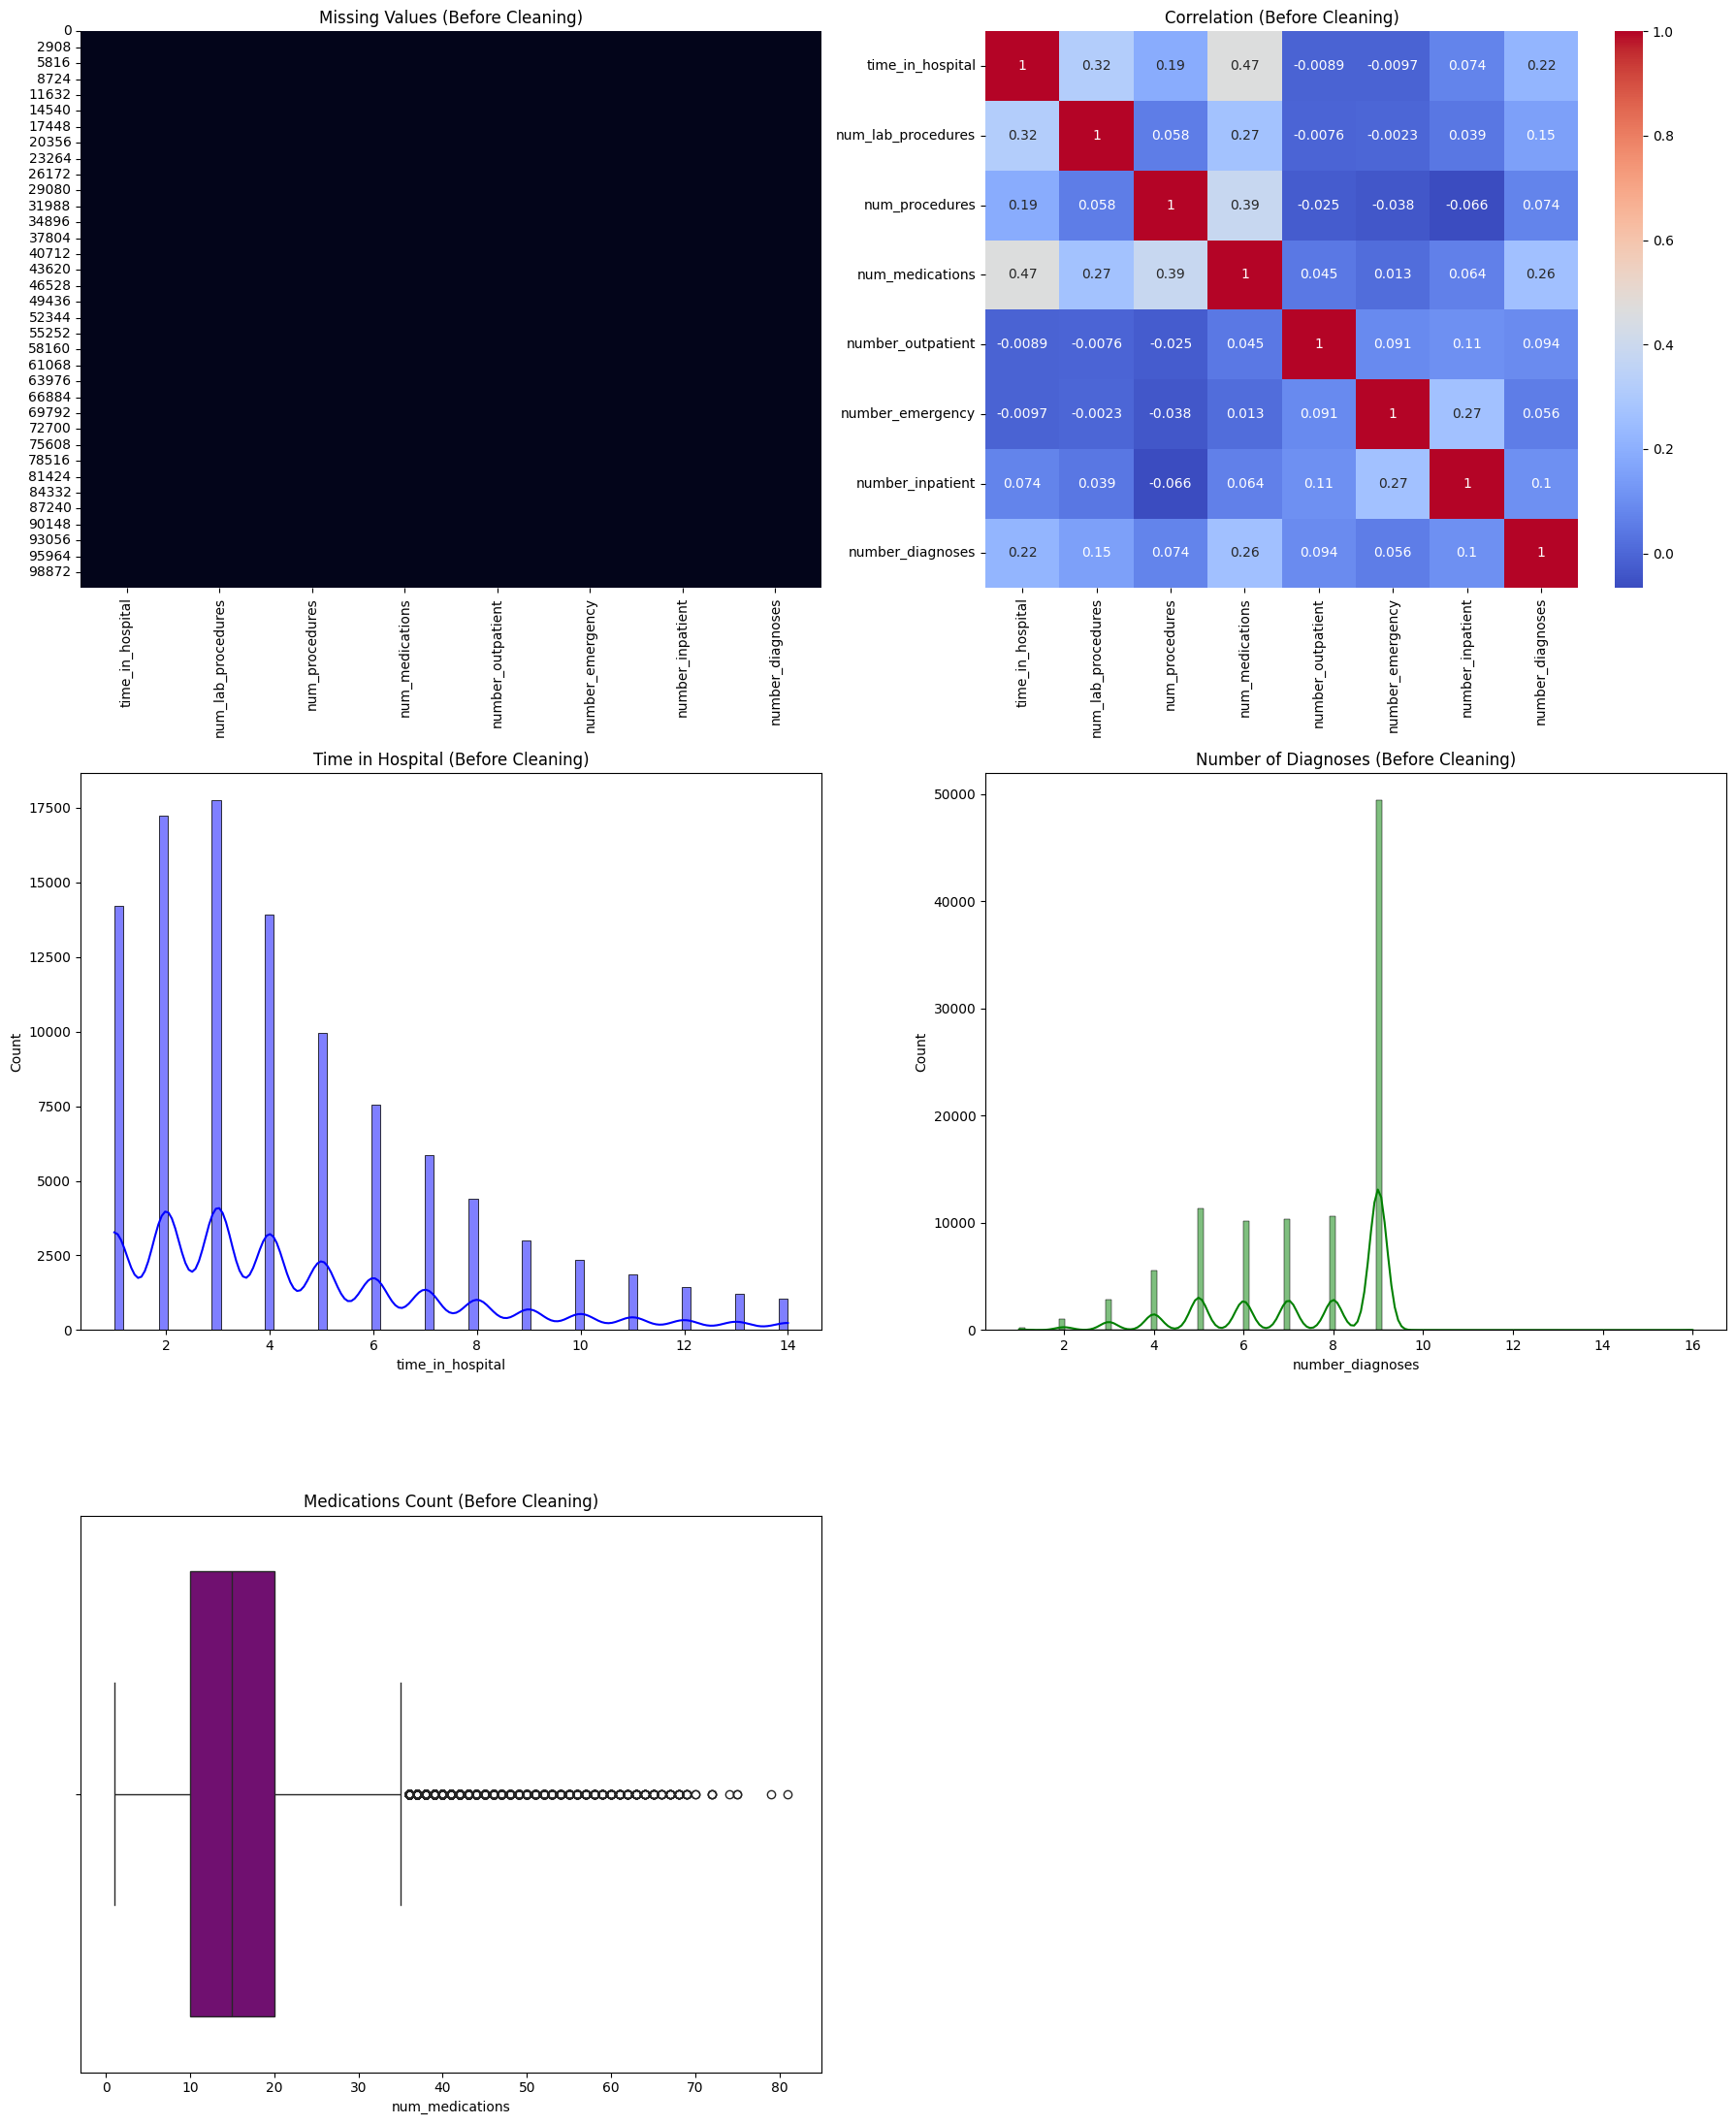

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses"
]

plt.figure(figsize=(18, 22))

# 1. Missing Values Heatmap
plt.subplot(3, 2, 1)
sns.heatmap(df_raw[numeric_cols].isna(), cbar=False)
plt.title("Missing Values (Before Cleaning)")

# 2. Correlation Heatmap
plt.subplot(3, 2, 2)
sns.heatmap(df_raw[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation (Before Cleaning)")

# 3. Distribution Plot
plt.subplot(3, 2, 3)
sns.histplot(df_raw["time_in_hospital"], kde=True, color="blue")
plt.title("Time in Hospital (Before Cleaning)")

# 4. Diagnoses Distribution
plt.subplot(3, 2, 4)
sns.histplot(df_raw["number_diagnoses"], kde=True, color="green")
plt.title("Number of Diagnoses (Before Cleaning)")

# 5. Boxplot
plt.subplot(3, 2, 5)
sns.boxplot(x=df_raw["num_medications"], color="purple")
plt.title("Medications Count (Before Cleaning)")

plt.tight_layout()
plt.show()


# **After Cleaning Graphs**

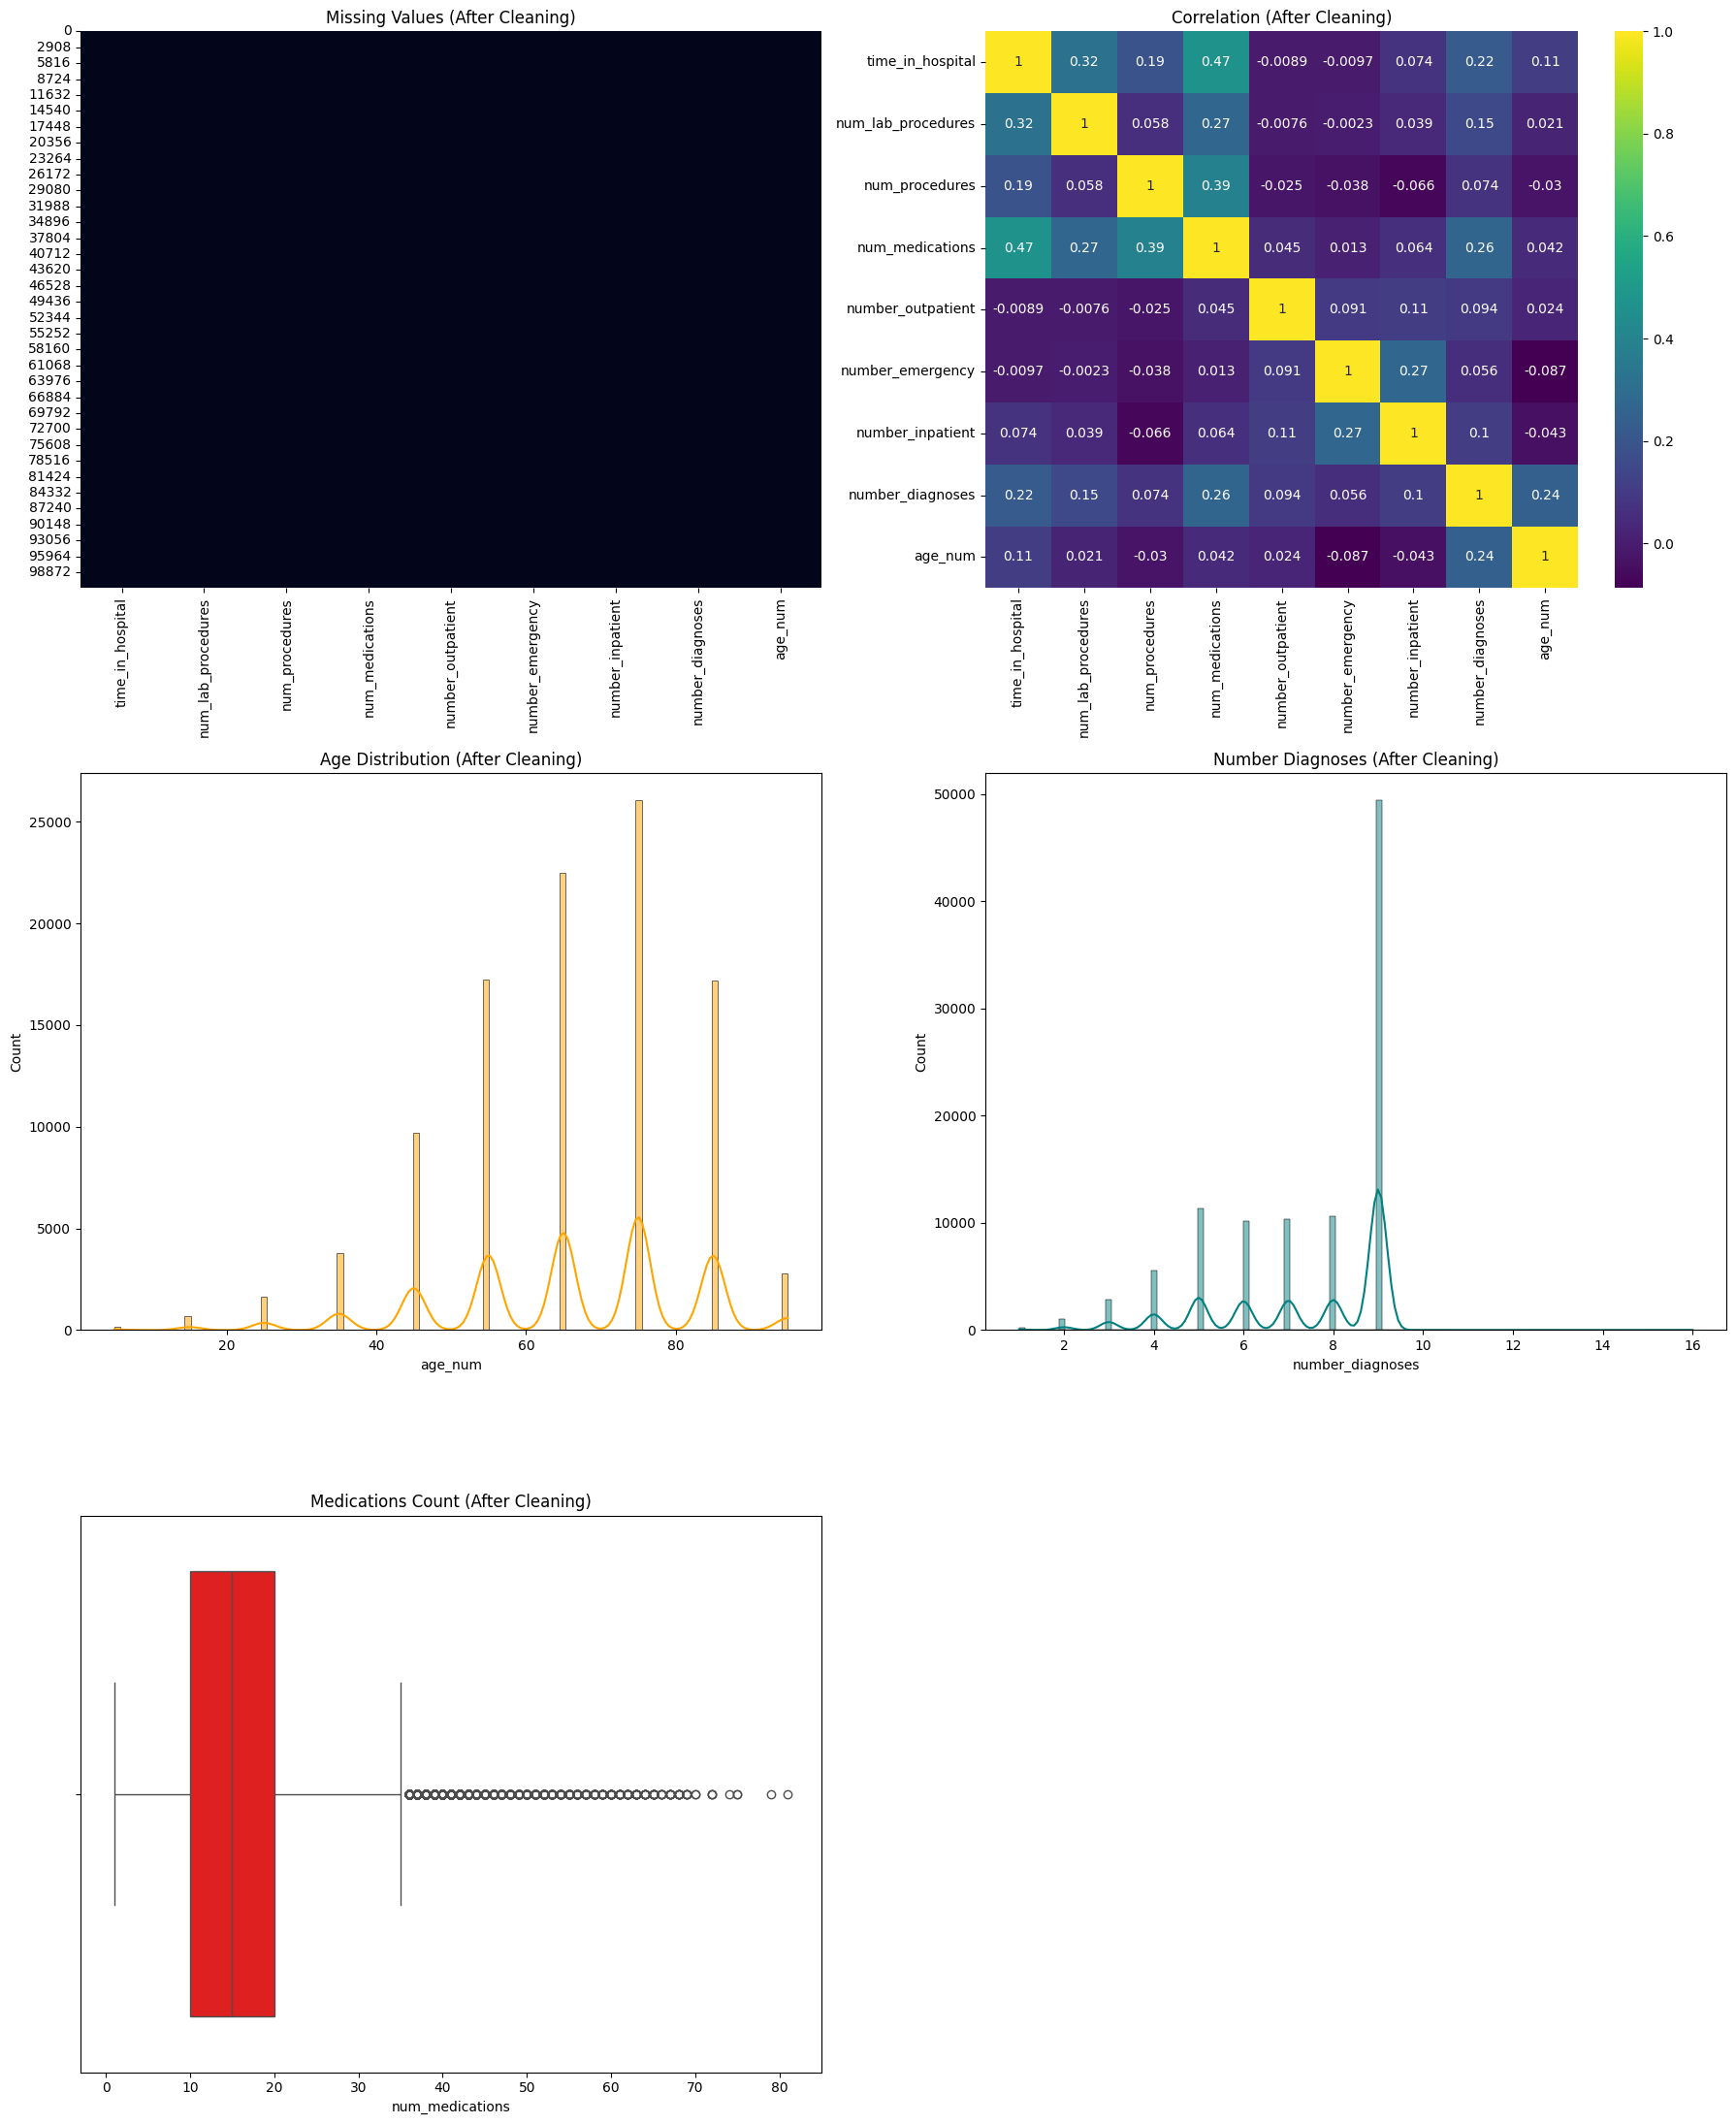

In [ ]:
plt.figure(figsize=(18, 22))

# 1. Missing Values Heatmap
plt.subplot(3, 2, 1)
sns.heatmap(df_clean[numeric_cols + ["age_num"]].isna(), cbar=False)
plt.title("Missing Values (After Cleaning)")

# 2. Correlation Heatmap
plt.subplot(3, 2, 2)
sns.heatmap(df_clean[numeric_cols + ["age_num"]].corr(), annot=True, cmap="viridis")
plt.title("Correlation (After Cleaning)")

# 3. Age_num Distribution
plt.subplot(3, 2, 3)
sns.histplot(df_clean["age_num"], kde=True, color="orange")
plt.title("Age Distribution (After Cleaning)")

# 4. Diagnoses Distribution
plt.subplot(3, 2, 4)
sns.histplot(df_clean["number_diagnoses"], kde=True, color="teal")
plt.title("Number Diagnoses (After Cleaning)")

# 5. Boxplot
plt.subplot(3, 2, 5)
sns.boxplot(x=df_clean["num_medications"], color="red")
plt.title("Medications Count (After Cleaning)")

plt.tight_layout()
plt.show()


# **Comparison of Before & After Cleaning**

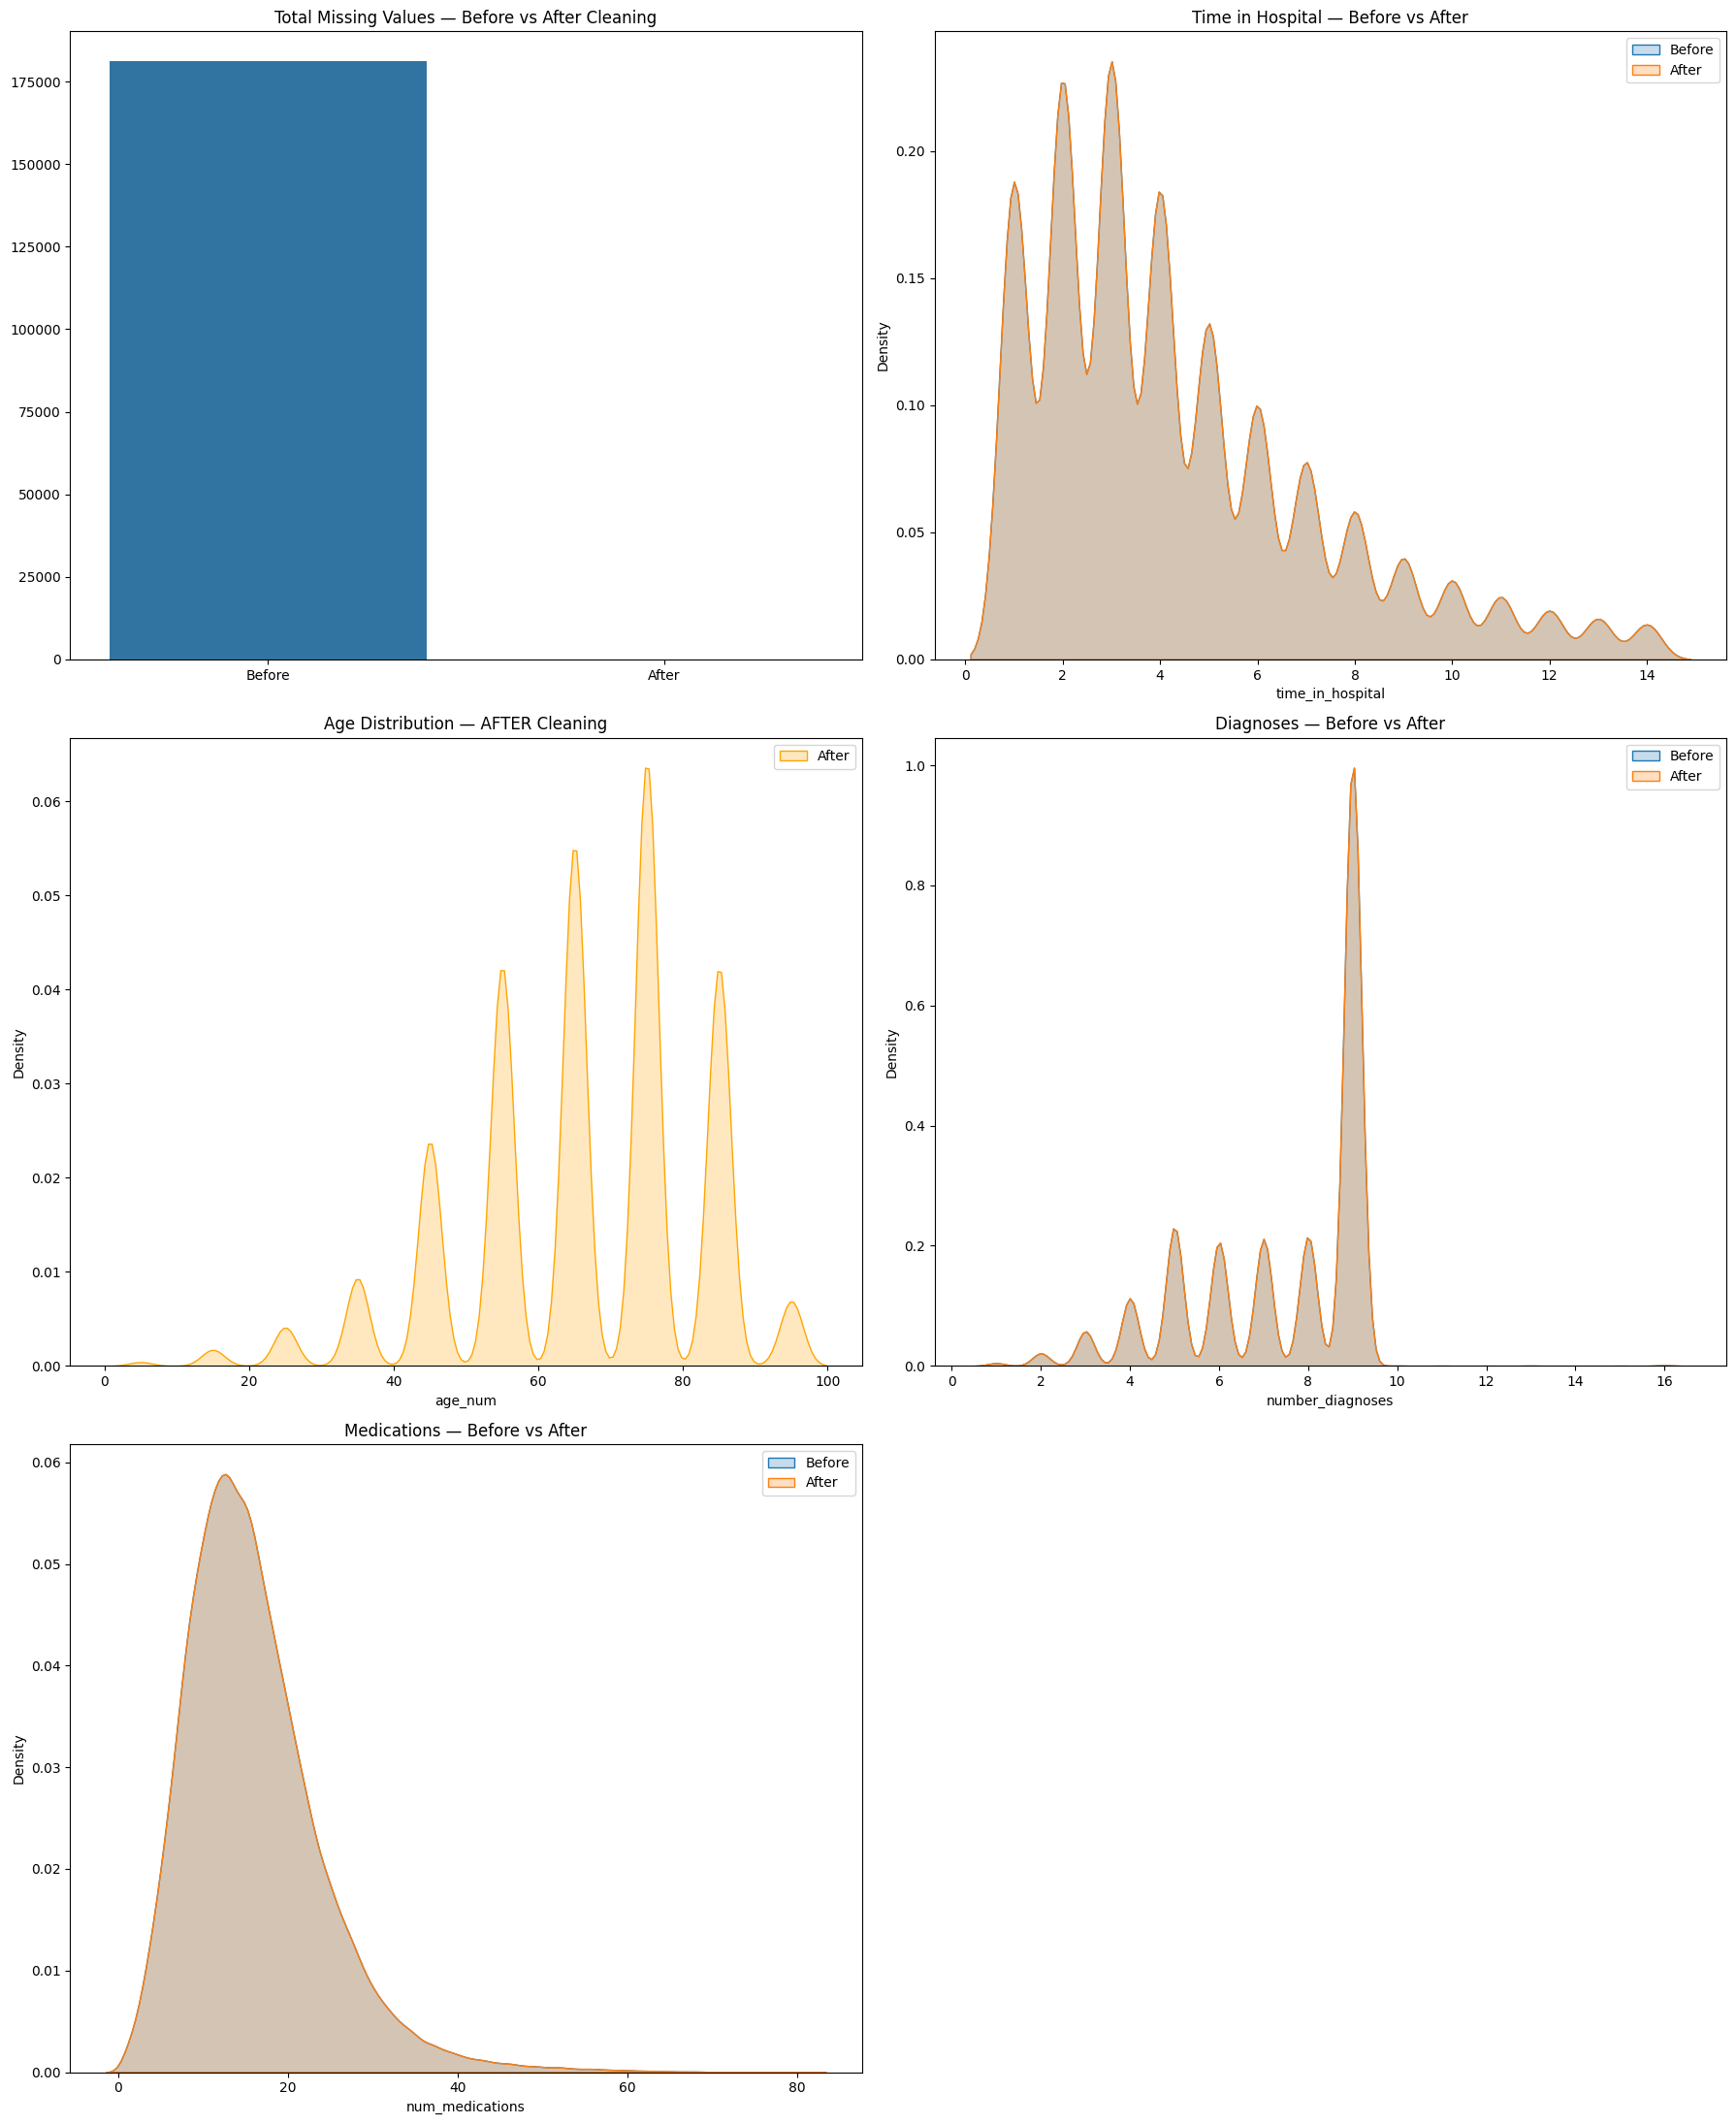

In [ ]:
plt.figure(figsize=(18, 22))

# 1. Missing Values Comparison
plt.subplot(3, 2, 1)
miss_before = df_raw.isna().sum().sum()
miss_after = df_clean.isna().sum().sum()
sns.barplot(x=["Before", "After"], y=[miss_before, miss_after])
plt.title("Total Missing Values — Before vs After Cleaning")

# 2. Time in Hospital KDE
plt.subplot(3, 2, 2)
sns.kdeplot(df_raw["time_in_hospital"], label="Before", fill=True)
sns.kdeplot(df_clean["time_in_hospital"], label="After", fill=True)
plt.title("Time in Hospital — Before vs After")
plt.legend()

# 3. Age Comparison (cleaned only because raw is a range text)
plt.subplot(3, 2, 3)
sns.kdeplot(df_clean["age_num"], label="After", fill=True, color="orange")
plt.title("Age Distribution — AFTER Cleaning")
plt.legend()

# 4. Diagnoses Comparison
plt.subplot(3, 2, 4)
sns.kdeplot(df_raw["number_diagnoses"], label="Before", fill=True)
sns.kdeplot(df_clean["number_diagnoses"], label="After", fill=True)
plt.title("Diagnoses — Before vs After")
plt.legend()

# 5. Medications Comparison
plt.subplot(3, 2, 5)
sns.kdeplot(df_raw["num_medications"], label="Before", fill=True)
sns.kdeplot(df_clean["num_medications"], label="After", fill=True)
plt.title("Medications — Before vs After")
plt.legend()

plt.tight_layout()
plt.show()


# **Classification & Regression Models**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape


((81412, 52), (20354, 52))

In [ ]:
# ================================
# LOGISTIC REGRESSION MODEL
# ================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("/content/diabetic_data.csv")


# ================================
# CREATE age_num COLUMN
# Convert age ranges like [20-30) → 25
# ================================

def convert_age(a):
    a = a.replace("[", "").replace(")", "")     # remove brackets
    low, high = a.split("-")
    return (int(low) + int(high)) / 2           # mid-value

df["age_num"] = df["age"].apply(convert_age)


# ================================
# TARGET COLUMN: readmitted_binary
# ================================

df["readmitted_binary"] = df["readmitted"].apply(lambda x: 0 if x == "NO" else 1)


# ================================
# SELECT FEATURES
# ================================

features = [
    "age_num",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

X = df[features]
y = df["readmitted_binary"]


# ================================
# TRAIN–TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# SCALING
# ================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================================
# LOGISTIC REGRESSION
# ================================

log = LogisticRegression(max_iter=500)
log.fit(X_train, y_train)

y_pred = log.predict(X_test)


# ================================
# RESULTS
# ================================

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6161933772231503

Confusion Matrix:
 [[8908 2044]
 [5768 3634]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.81      0.70     10952
           1       0.64      0.39      0.48      9402

    accuracy                           0.62     20354
   macro avg       0.62      0.60      0.59     20354
weighted avg       0.62      0.62      0.60     20354



In [ ]:
# =============================================
# DECISION TREE CLASSIFIER (Objective: Next Model)
# =============================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    random_state=42
)

# Train model
dt.fit(X_train, y_train)

# Predictions
dt_pred = dt.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))


Decision Tree Accuracy: 0.6181094625135108

Confusion Matrix:
 [[8033 2919]
 [4854 4548]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.73      0.67     10952
           1       0.61      0.48      0.54      9402

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.62      0.62      0.61     20354



In [ ]:
# =============================================
# RANDOM FOREST CLASSIFIER (Next Model)
# =============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.6243981526972585

Confusion Matrix:
 [[8164 2788]
 [4857 4545]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.75      0.68     10952
           1       0.62      0.48      0.54      9402

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.62      0.62      0.62     20354



In [ ]:
# =============================================
# KNN CLASSIFIER (Next Model)
# =============================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the KNN model
knn = KNeighborsClassifier(
    n_neighbors=5,      # You can tune this later
    metric='minkowski',
    p=2                 # Euclidean distance
)

# Train the model
knn.fit(X_train, y_train)

# Predictions
knn_pred = knn.predict(X_test)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred))


KNN Accuracy: 0.5757590645573352

Confusion Matrix:
 [[6969 3983]
 [4652 4750]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.64      0.62     10952
           1       0.54      0.51      0.52      9402

    accuracy                           0.58     20354
   macro avg       0.57      0.57      0.57     20354
weighted avg       0.57      0.58      0.57     20354



In [ ]:
# =====================================================
# GRADIENT BOOSTING CLASSIFIER (Next Model)
# =====================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gb.fit(X_train, y_train)

# Predictions
gb_pred = gb.predict(X_test)

# Evaluation
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, gb_pred))
print("\nClassification Report:\n", classification_report(y_test, gb_pred))


Gradient Boosting Accuracy: 0.6222855458386558

Confusion Matrix:
 [[8239 2713]
 [4975 4427]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.75      0.68     10952
           1       0.62      0.47      0.54      9402

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.62      0.62      0.61     20354



In [ ]:
# =====================================================
# XGBOOST CLASSIFIER (Next Model)
# =====================================================

!pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="binary:logistic"
)

# Train
xgb.fit(X_train, y_train)

# Predictions
xgb_pred = xgb.predict(X_test)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))


XGBoost Accuracy: 0.625282499754348

Confusion Matrix:
 [[8252 2700]
 [4927 4475]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.75      0.68     10952
           1       0.62      0.48      0.54      9402

    accuracy                           0.63     20354
   macro avg       0.62      0.61      0.61     20354
weighted avg       0.63      0.63      0.62     20354



In [ ]:
# =====================================================
# FINAL SUMMARY — MODEL COMPARISON
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Store all model accuracies
accuracy_data = {
    "Logistic Regression": accuracy_score(y_test, y_pred),      # from Logistic Regression block
    "Decision Tree": accuracy_score(y_test, dt_pred),           # from Decision Tree block
    "Random Forest": accuracy_score(y_test, rf_pred),           # from Random Forest block
    "KNN": accuracy_score(y_test, knn_pred),                    # from KNN block
    "Gradient Boosting": accuracy_score(y_test, gb_pred),       # from GB block
    "XGBoost": accuracy_score(y_test, xgb_pred)                 # from XGBoost block
}

# Convert to DataFrame
summary_df = pd.DataFrame.from_dict(accuracy_data, orient='index', columns=["Accuracy"])
summary_df = summary_df.sort_values("Accuracy", ascending=False)

summary_df


,Accuracy
XGBoost,0.625282
Random Forest,0.624398
Gradient Boosting,0.622286
Decision Tree,0.618109
Logistic Regression,0.616193
KNN,0.575759


# **Comparison Of Models**

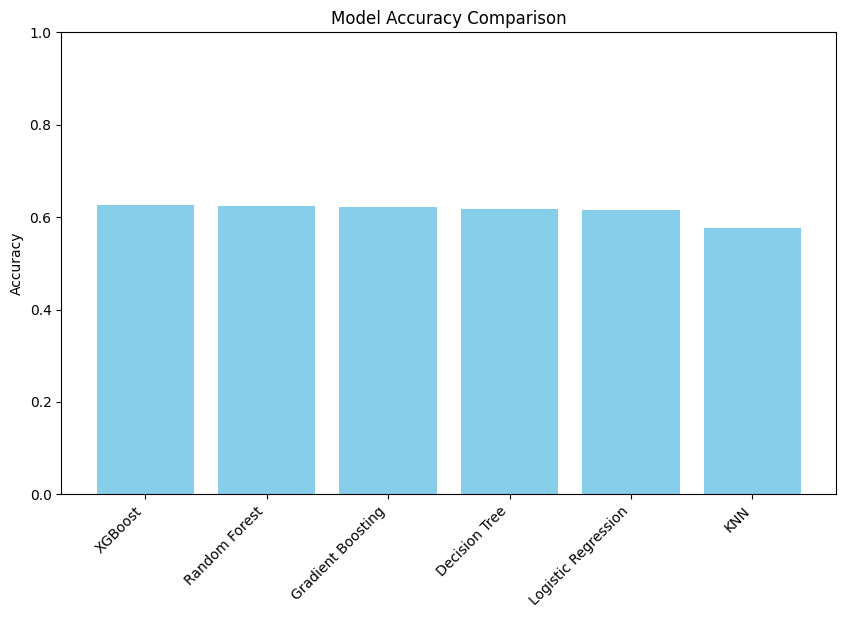

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(summary_df.index, summary_df["Accuracy"], color="skyblue")
plt.xticks(rotation=45, ha='right')
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


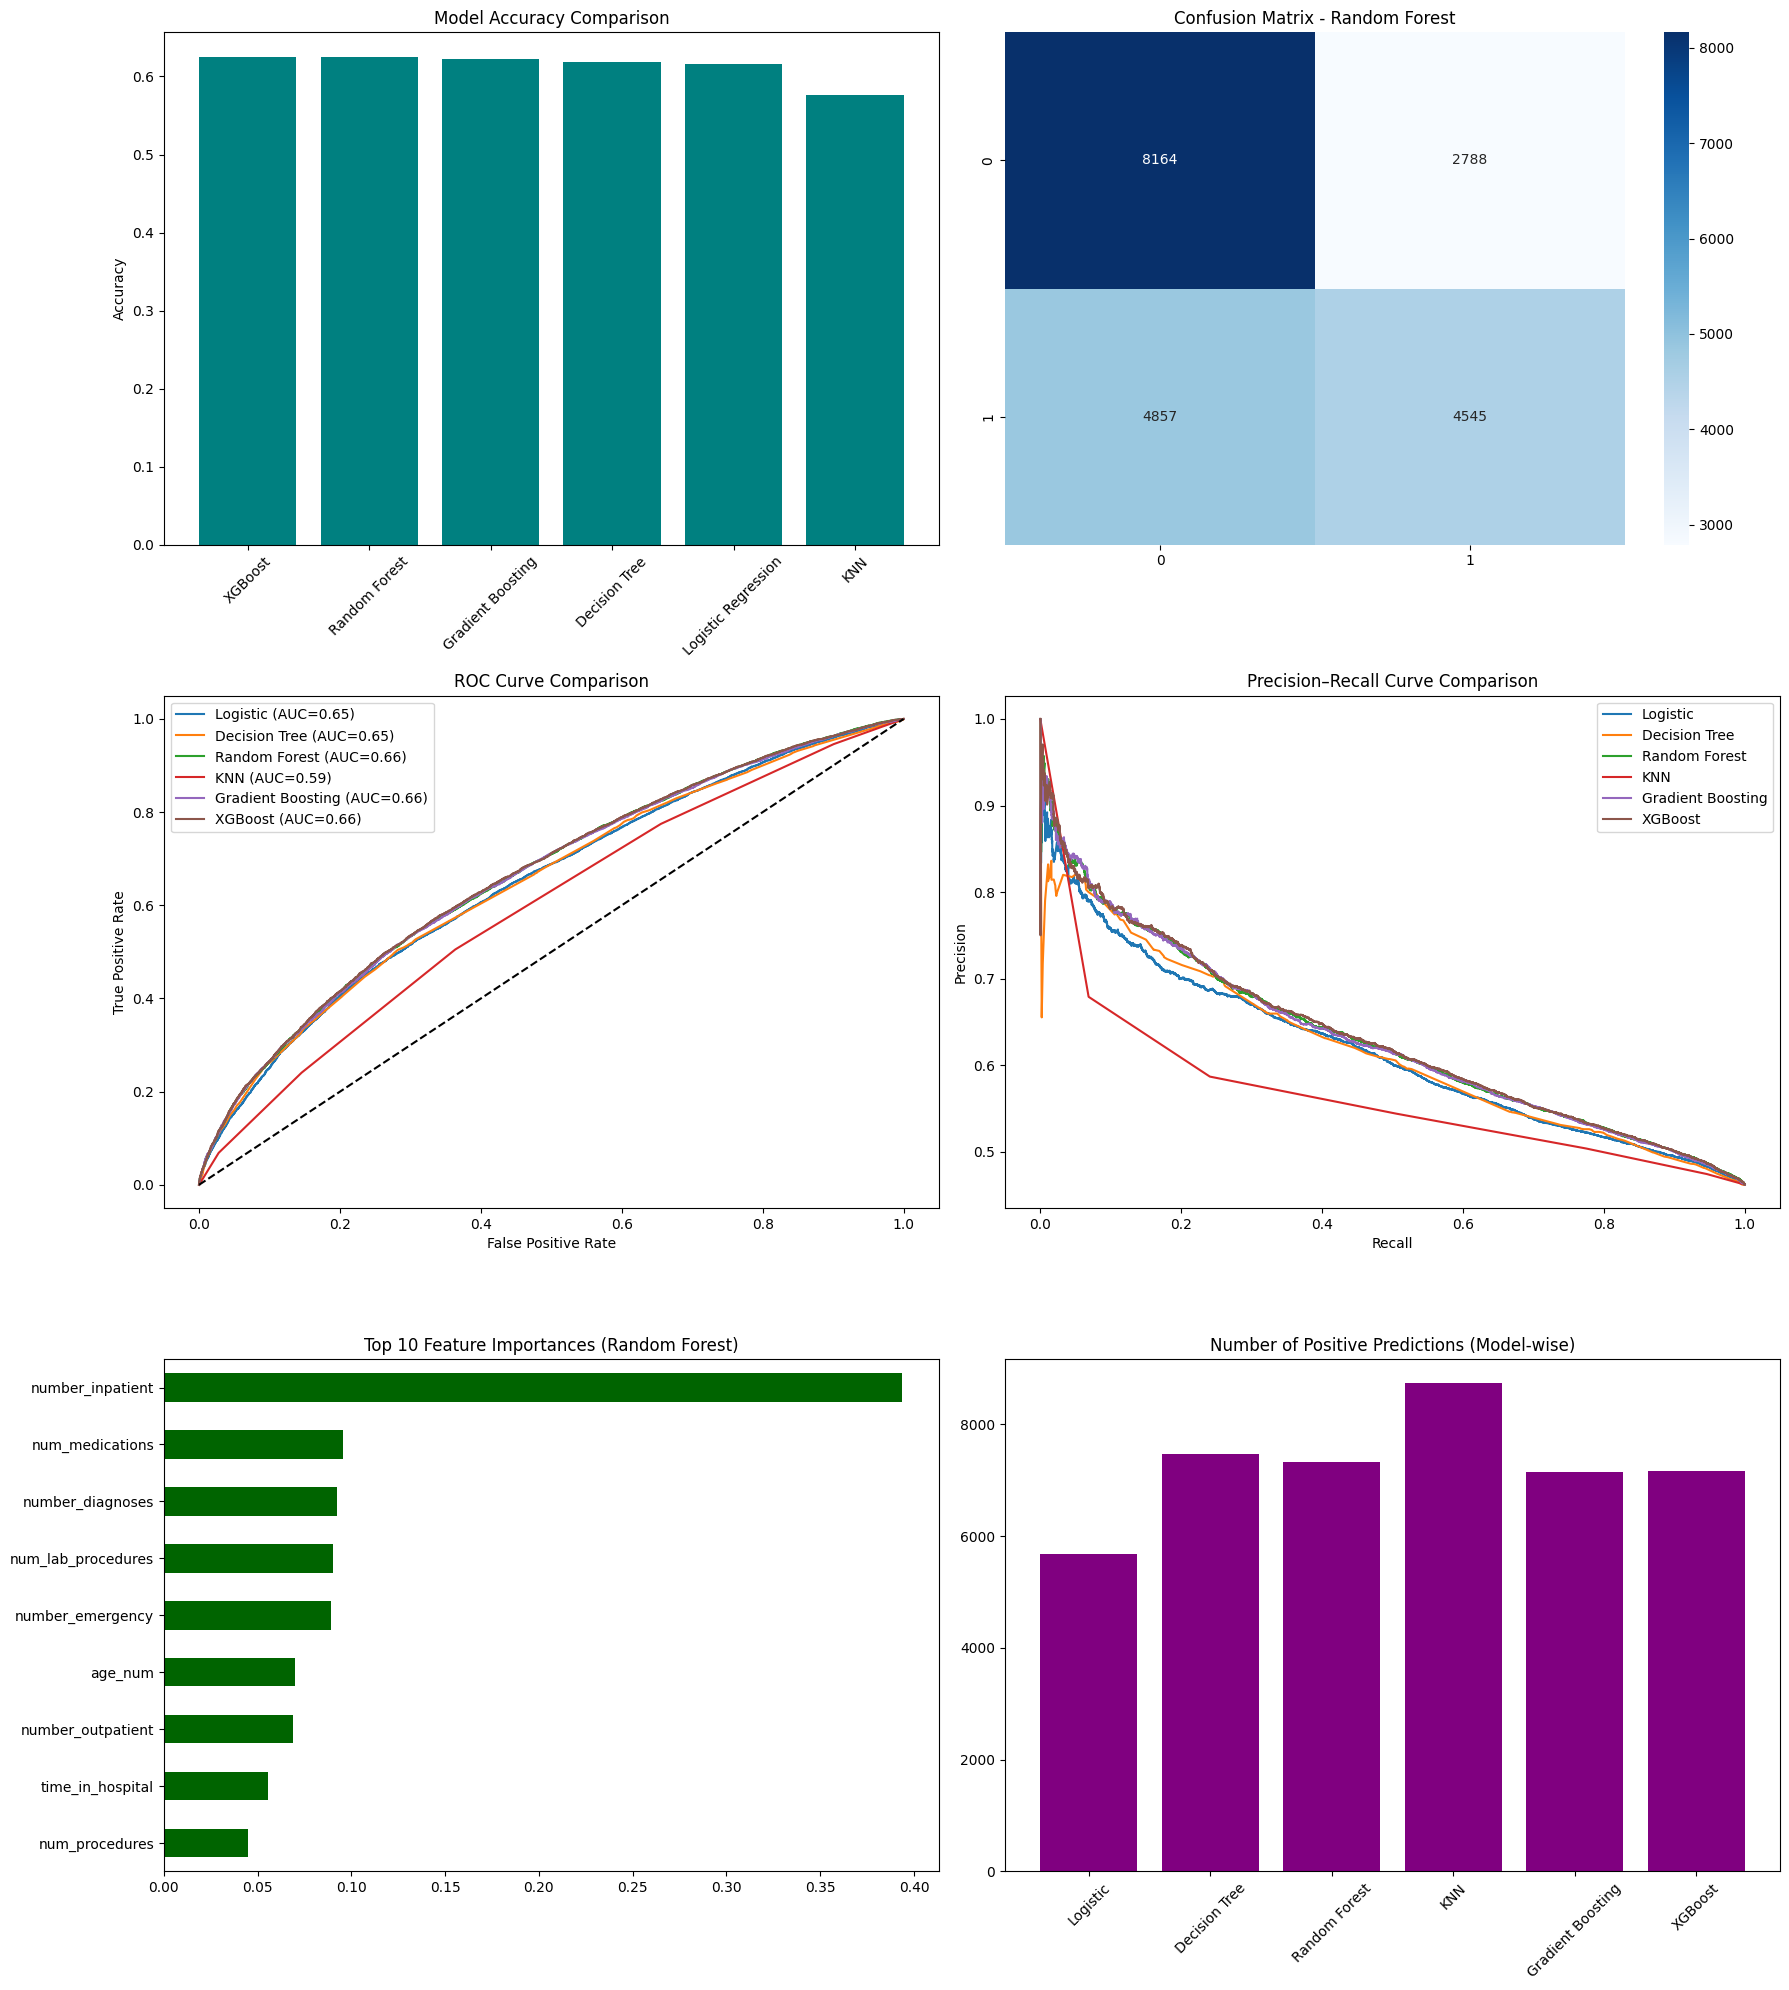

In [ ]:
# ============================================================
# MODEL COMPARISON DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

models = {
    "Logistic": log,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

plt.figure(figsize=(18, 20))

# ------------------------------------------------------------
# 1️⃣ Accuracy Bar Chart
# ------------------------------------------------------------
plt.subplot(3, 2, 1)
plt.bar(summary_df.index, summary_df["Accuracy"], color="teal")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

# ------------------------------------------------------------
# 2️⃣ Confusion Matrix (Random Forest)
# ------------------------------------------------------------
plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Random Forest")

# ------------------------------------------------------------
# 3️⃣ ROC Curve (ALL MODELS)
# ------------------------------------------------------------
plt.subplot(3, 2, 3)
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# ------------------------------------------------------------
# 4️⃣ Precision–Recall Curve
# ------------------------------------------------------------
plt.subplot(3, 2, 4)
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    plt.plot(recall, precision, label=name)

plt.title("Precision–Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

# ------------------------------------------------------------
# 5️⃣ Feature Importance (Random Forest)
# ------------------------------------------------------------
plt.subplot(3, 2, 5)
importances = pd.Series(rf.feature_importances_, index=X.columns)
imp_sorted = importances.sort_values(ascending=False)[:10]
imp_sorted.plot(kind="barh", color="darkgreen")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()

# ------------------------------------------------------------
# 6️⃣ Model Prediction Distribution
# ------------------------------------------------------------
plt.subplot(3, 2, 6)
pred_counts = {
    name: model.predict(X_test).sum()
    for name, model in models.items()
}
plt.bar(pred_counts.keys(), pred_counts.values(), color="purple")
plt.title("Number of Positive Predictions (Model-wise)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
!pip install cloudflared


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 1.8 MB/s eta 0:00:00
  Created wheel for cloudflared: filename=cloudflared-1.0.0.2-py3-none-any.whl size=2983 sha256=ffc50ab3a577bc36d53bfc9fcf808820490a9f817f0e41a3571820c349bad1ba
  Stored in directory: /root/.cache/pip/wheels/5b/ec/09/c3bcd3470be046ec77a9c0cb9d8bb6ceed49c831460878ab0a
Successfully built cloudflared


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb
!streamlit run app.py & cloudflared tunnel --url http://localhost:8501


(Reading database ... 121717 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2025.11.1) over (2025.11.1) ...
Setting up cloudflared (2025.11.1) ...
Processing triggers for man-db (2.10.2-1) ...
2025-11-22T11:49:09Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-11-22T11:49:09Z INF Requesting new quick Tunnel on trycloudflare.com...


2025-11-22T11:49:12Z INF +----------------------------